In [ ]:
import ast

s = '''
match x:
    case Point.Var(P(), "y"):
        pass

'''

print(ast.dump(ast.parse(s), indent=2))

outputsaaa:  []


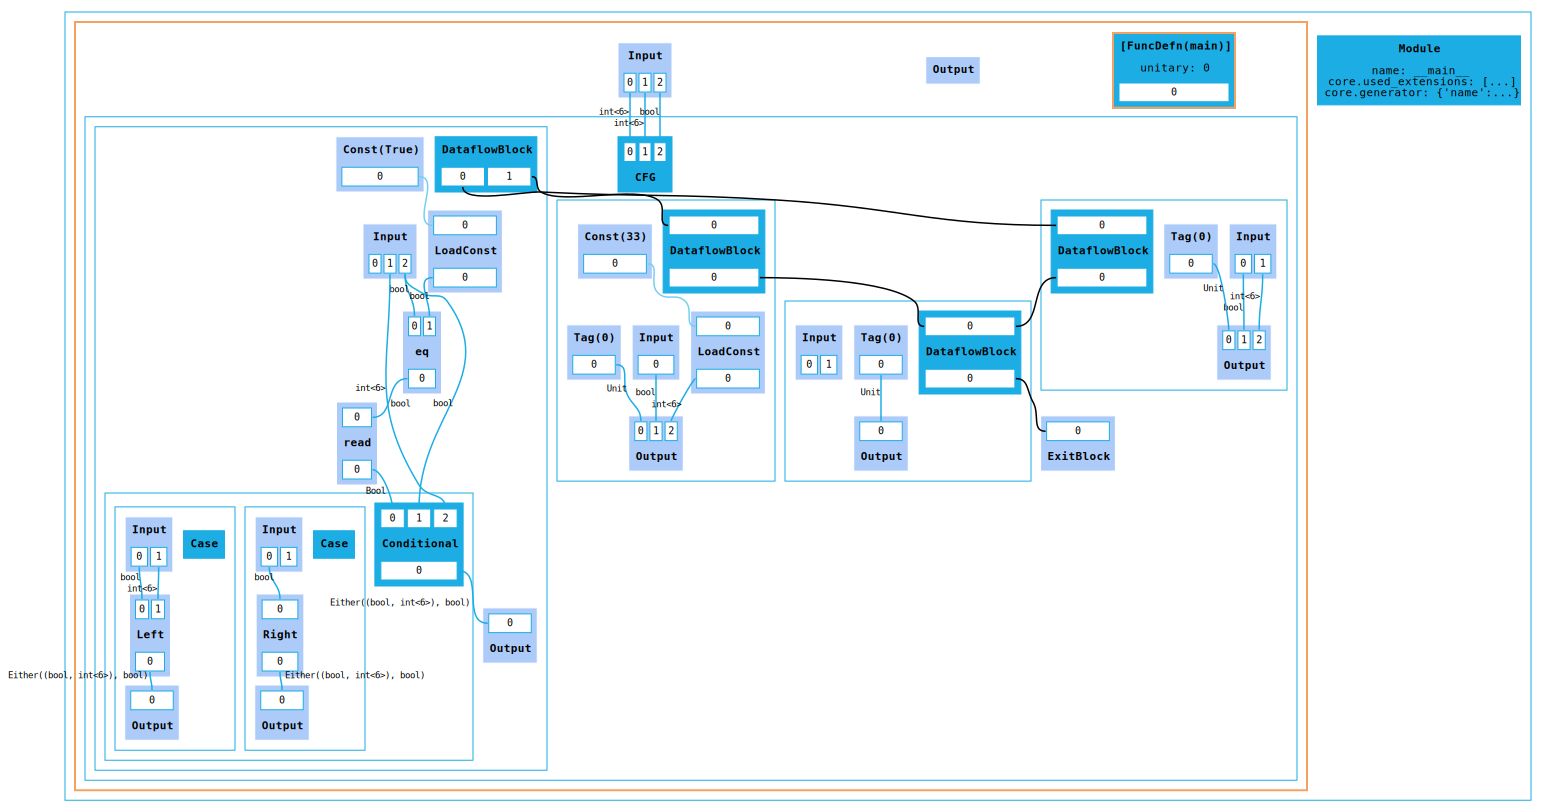

In [4]:
from guppylang import guppy
from guppylang.std.quantum import qubit, h, measure, x
from hugr.hugr.render import RenderConfig

@guppy.struct
class Point:
    x: int
    y: int


@guppy
def main(a: int, q: int, c : bool) -> None:

    if c == True:
        q = 33
    else:
        pass

    a = q
    d = c
    
main.compile_function().modules[0].render_dot(RenderConfig(max_edge_label_length=1000))

In [ ]:
from guppylang import guppy
from guppylang.std.quantum import qubit
from hugr.hugr.render import RenderConfig

@guppy.struct
class Point:
    x: int
    y: int
    z : int


@guppy
def main(a: int, b: bool, c : bool) -> int:
    s2 = Point(0, 2, 7)
    s = Point(1, 2, 3)
    match s:
        case Point(1, _, _):
            s2 = Point(0, 2, 7)

    s1 = s
    return s1.x
    
    

main.compile_function().modules[0].render_dot()

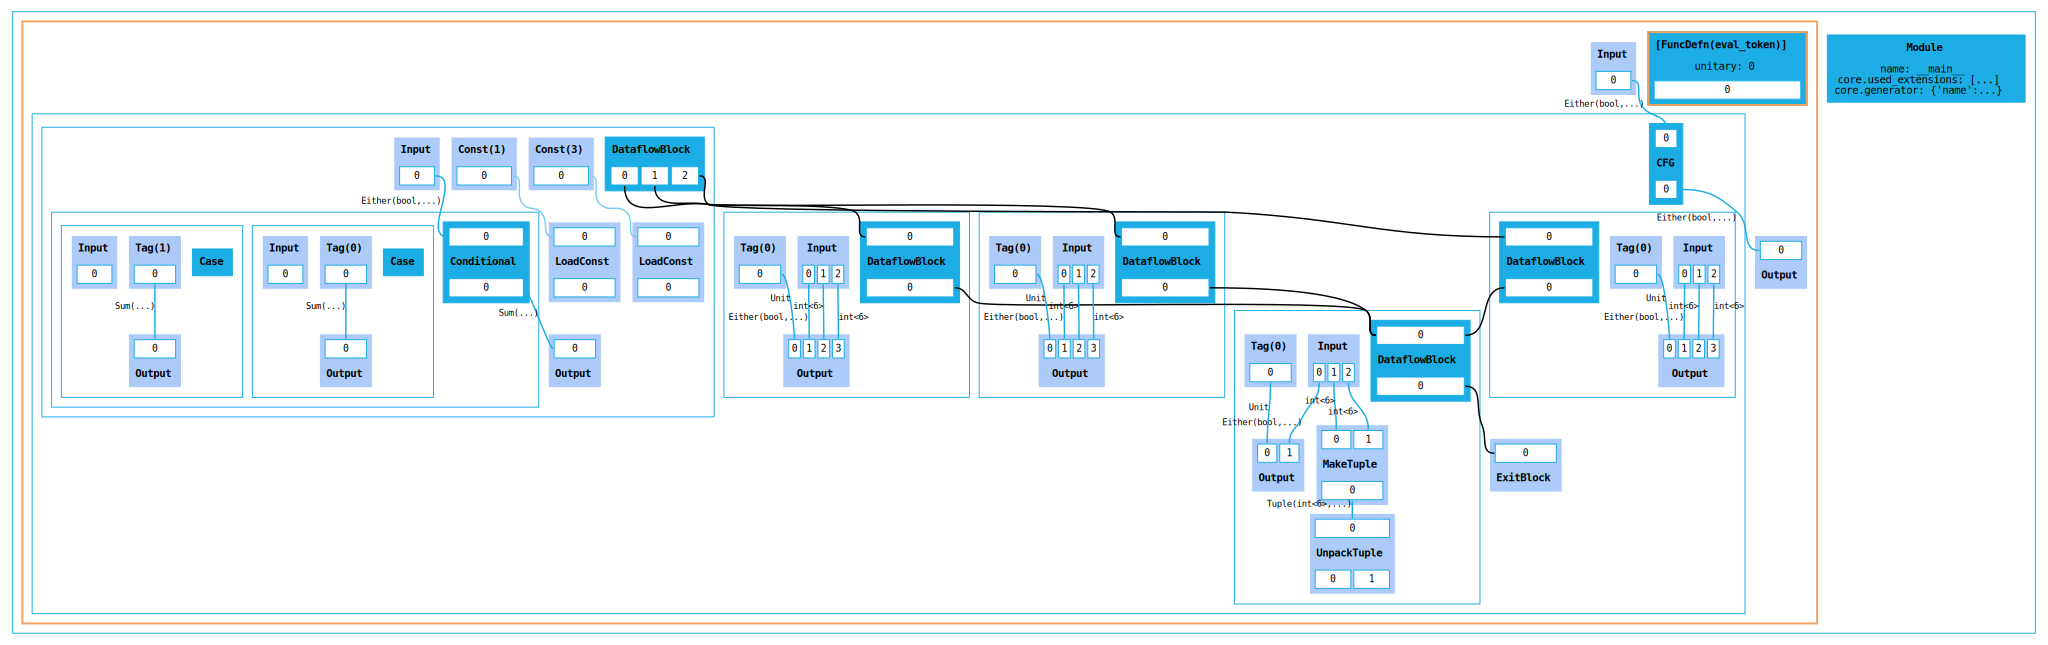

In [1]:
from guppylang import guppy
from selene_hugr_qis_compiler import check_hugr


@guppy.enum
class Token:
    # else_cond = {}
    bool_lit = {"b": bool}
    int_lit = {"n": int}
    # second_cond = {}



@guppy
def eval_token(t: Token) -> Token:
    x = 1
    y = 3
    match t:
        case Token.int_lit(_):
            pass
        case Token.bool_lit(_):
            pass
        case _:
            pass

    z =x, y

    return t

h = eval_token.compile_function().modules[0]
# check_hugr(h.to_bytes())
h.render_dot()


outputsaaa:  []
outputsaaa:  []


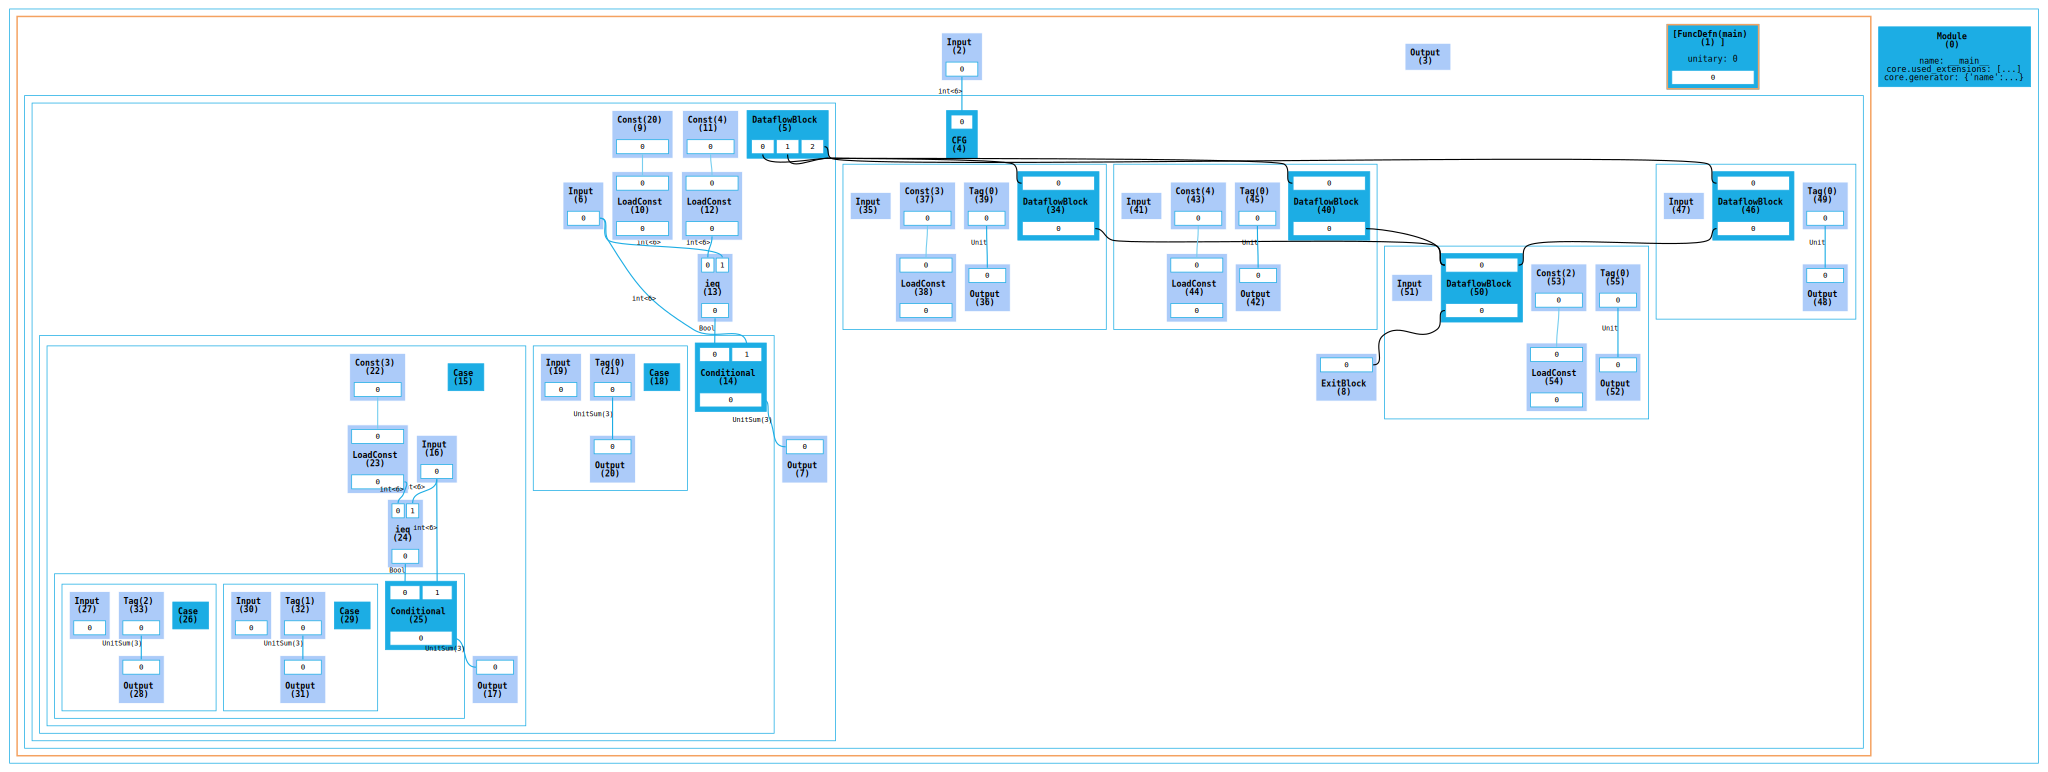

In [1]:


# Example: linear variable used in multiple match arms (should error if not allowed)
from guppylang import guppy
from guppylang.std.quantum import qubit, measure, owned
from selene_hugr_qis_compiler import check_hugr
from hugr.hugr.render import RenderConfig

@guppy
def fun() -> int:
    return 42

@guppy
def main(a:int) -> None:
    x = 20
    match a:
        case 4:
            x = 3
        case 3:
            x = 4


    b =  2


hu = main.compile_function().modules[0]
with open("hugr_output.dot", "w") as f:
    f.write(str(hu.render_dot(config=RenderConfig(max_edge_label_length=100, display_node_id=True))))
check_hugr(hu.to_bytes())
main.compile_function().modules[0].render_dot(RenderConfig(max_edge_label_length=100, display_node_id=True))


In [ ]:
# Example: linear variable used in multiple match arms (should error if not allowed)
from guppylang import guppy
from guppylang.std.quantum import qubit, measure, h

@guppy.struct
class Point:
    x: qubit
    y: int

@guppy
def fun() -> Point:
    return Point(qubit(), 4)

@guppy
def describe_point(point: Point)-> None:
    pass

@guppy
def main(p: Point) -> None:

    describe_point(fun())

main.check()


In [ ]:
from guppylang import guppy
from hugr.hugr.render import RenderConfig

@guppy.enum
class Point:
    x = {"n": int}
    y = {"n": int}
    z = {"n": int}

    @guppy
    def enum(self: Point) -> None:
        pass

@guppy.struct
class Line:
    start: int
    end: int

    @guppy
    def struct(self: Line) -> None:
        pass

@guppy
def main() -> None:
    p = Point.x(1)
    p.enum()
    l = Line(2, 3)
    l.struct()

main.compile_function().modules[0].render_dot(RenderConfig(max_edge_label_length=100)).view()
    

In [ ]:
a = [1,2,3,4]

[(i, a) for i, a in enumerate(a) if a % 2 == 0]